<a href="https://colab.research.google.com/github/zhouning/arcgis-farmland-mpc/blob/main/notebooks/farmland_mpc_colab_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `farmland-mpc` — End-to-End Colab Demo

**Model-based AI planning for county-scale farmland consolidation in fragmented mountain landscapes.**

This notebook runs the **complete 4-phase pipeline** on a synthetic 36-parcel fixture:

1. **Prepare** (Phase A+B+C): DEM → slope → block definition → sanity check
2. **Sample** (Phase B): random-policy transitions + pairwise ranking data
3. **Train** (Phase C): contrastive world-model ensemble → ONNX export
4. **Plan** (Phase D): MPC rollout → optimised land-use shapefile

No proprietary GIS dependencies. Runs entirely in Colab on CPU in ~2 minutes.

Repository: https://github.com/zhouning/arcgis-farmland-mpc

---

## 1. Install dependencies

Colab pre-installs `numpy`, `scipy`, `matplotlib`, `scikit-learn`, `networkx`, `torch`. We add the geospatial stack and pull `farmland-mpc` from GitHub.

In [1]:
!pip install --quiet geopandas rasterio pyogrio shapely fiona libpysal typer tqdm onnx onnxruntime onnxscript gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.0 MB/s eta 0:00:00


In [2]:
# Install farmland-mpc from the public GitHub repo.
# If the repo is still private, use a personal access token:
#   !pip install --quiet git+https://<token>@github.com/zhouning/arcgis-farmland-mpc.git
!pip install --quiet git+https://github.com/zhouning/arcgis-farmland-mpc.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import farmland_mpc
import torch, rasterio, geopandas as gpd

print(f'farmland_mpc: {farmland_mpc.__version__}')
print(f'torch:        {torch.__version__}')
print(f'rasterio:     {rasterio.__version__}')
print(f'geopandas:    {gpd.__version__}')

farmland_mpc: 0.1.0
torch:        2.10.0+cpu
rasterio:     1.5.0
geopandas:    1.1.3


## 2. Synthesise a 36-parcel toy region

We build a 12×6 grid of 100m parcels (= 1 ha each) across 2 townships, with a mix of farmland (DLBM 011/012, ~60%) and forest (DLBM 031, ~40%). A tilted-plane DEM with a Gaussian bump provides slope variation. CRS: UTM Zone 48N (WKT, bypasses EPSG database).

In [4]:
import tempfile, json
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import box

CRS_WKT = (
    'PROJCRS["WGS 84 / UTM zone 48N",'
    'BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",'
    'ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],'
    'PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]]],'
    'CONVERSION["UTM zone 48N",METHOD["Transverse Mercator",ID["EPSG",9807]],'
    'PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433]],'
    'PARAMETER["Longitude of natural origin",105,ANGLEUNIT["degree",0.0174532925199433]],'
    'PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1]],'
    'PARAMETER["False easting",500000,LENGTHUNIT["metre",1]],'
    'PARAMETER["False northing",0,LENGTHUNIT["metre",1]]],'
    'CS[Cartesian,2],'
    'AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],'
    'AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]]]'
)

work = Path(tempfile.mkdtemp(prefix='farmland_mpc_colab_'))
dem_path  = work / 'dem.tif'
dltb_path = work / 'dltb.shp'
prepared  = work / 'prepared'

GRID = 6
CELL_M = 100.0
DEM_RES = 30.0
ox, oy = 500000.0, 4400000.0

# DEM: tilted plane + Gaussian bump (covers both townships)
grid_w = 2 * GRID  # 12 parcels wide
grid_h = GRID
px_w = int(grid_w * CELL_M / DEM_RES)
px_h = int(grid_h * CELL_M / DEM_RES)
xs, ys = np.arange(px_w) * DEM_RES, np.arange(px_h) * DEM_RES
xx, yy = np.meshgrid(xs, ys)
z = 100 + 0.04 * xx + 0.015 * yy
bump = 80.0 * np.exp(-((xx - 0.75*px_w*DEM_RES)**2 + (yy - 0.25*px_h*DEM_RES)**2) / (2*(50*DEM_RES)**2))
z = z + bump
tf = from_origin(ox, oy, DEM_RES, DEM_RES)
with rasterio.open(dem_path, 'w', driver='GTiff', dtype='float32', nodata=-9999.0,
                   width=px_w, height=px_h, count=1, crs=CRS_WKT, transform=tf) as dst:
    dst.write(z.astype('float32'), 1)

# DLTB: 12x6 grid, left half -> township 500227001, right -> 500227002
rng = np.random.default_rng(42)
rows = []
pid = 0
for col in range(grid_w):
    for row in range(grid_h):
        x0 = ox + col * CELL_M
        y1 = oy - row * CELL_M
        geom = box(x0, y1 - CELL_M, x0 + CELL_M, y1)
        twn = '500227001' if col < GRID else '500227002'
        r = rng.random()
        dlbm = '011' if r < 0.5 else ('012' if r < 0.6 else '031')
        dlmc = {'011': '水田', '012': '水浇地', '031': '有林地'}[dlbm]
        pid += 1
        rows.append({'BSM': f'P{pid:04d}', 'DLBM': dlbm, 'DLMC': dlmc,
                     'QSDWDM': twn, 'geometry': geom})

gdf = gpd.GeoDataFrame(rows, crs=CRS_WKT)
gdf.to_file(dltb_path, driver='ESRI Shapefile', encoding='utf-8')
print(f'Wrote {len(gdf)} parcels ({(gdf.DLBM.str.startswith("01")).sum()} farmland, '
      f'{(gdf.DLBM=="031").sum()} forest) across {gdf.QSDWDM.nunique()} townships')
print(f'DEM: {px_w}x{px_h} pixels at {DEM_RES}m resolution')

Wrote 72 parcels (41 farmland, 31 forest) across 2 townships
DEM: 40x20 pixels at 30.0m resolution


## 3. Phase A+B+C: Prepare (DEM → slope → blocks)

`farmland_mpc.prepare.run` does three things:
- **A**: Reproject DEM, compute Horn 3×3 slope, zonal mean per parcel
- **B**: Extract townships from QSDWDM, define blocks via Paper 3 hybrid algorithm
- **C**: Sanity-check by instantiating the gymnasium environment

In [5]:
from farmland_mpc.prepare import run as prepare_run

out_shp = prepare_run(
    dltb_path=dltb_path,
    dem_path=dem_path,
    prepared_dir=prepared,
    proj_crs=CRS_WKT,
    run_phase_bc=True,
    min_parcels=2,
    min_area_ha=0.0,
    max_parcels=20,
    min_parcels_per_township=10,
)
summary = json.loads((prepared / 'prepare_data_summary.json').read_text(encoding='utf-8'))
print(f"\nPrepare done:")
print(f"  Parcels: {summary['n_parcels']}")
print(f"  Townships: {summary.get('townships', {}).get('n_townships', '?')}")
print(f"  Blocks: {summary.get('phase_b', {}).get('total_blocks', '?')}")
print(f"  Env n_parcels: {summary.get('phase_c_sanity', {}).get('n_parcels', '?')}")
print(f"  Env n_blocks: {summary.get('phase_c_sanity', {}).get('n_blocks', '?')}")


  Block Definition: 500227001
  Step 1: Loading parcels...
    Total: 36 parcels
    Farmland: 18
    Forest: 18
    Barriers: 0
    Other: 0

  Step 2: 36 swappable parcels extracted
  Step 3: Building adjacency (Queen contiguity)...
  Step 4: Finding connected components...
    Raw components: 1
  Step 5: Subdividing large components...
    After subdivision (max 20 parcels/block): 2 blocks
    After filtering (>=2 parcels, >=0.0 ha): 2 blocks
    Dropped parcels (tiny fragments): 0
    Assigned parcels: 36 / 36
  Step 8: Computing block features...

  === Block Summary ===
    Blocks: 2
    Parcels per block: min=12, median=18, max=24
    Area (ha): min=12.00, median=18.00, max=24.00, total=36.00
    Blocks >= 6.67 ha (百亩方): 2
    Blocks >= 33.3 ha (500亩): 0
  Saved to /tmp/farmland_mpc_colab_ur50oohk/prepared/results_real/blocks/township_500227001

  Block Definition: 500227002
  Step 1: Loading parcels...
    Total: 36 parcels
    Farmland: 23
    Forest: 13
    Barriers: 0
    O

## 4. Phase B: Sample transitions + pairwise data

Random-policy rollouts on the block-level MDP produce training data for the world model.

In [6]:
from farmland_mpc.sample import run as sample_run

sample_summary = sample_run(
    prepared_dir=prepared,
    n_transition_episodes=5,
    n_pairwise_states=20,
    n_pairwise_actions=4,
    seed=0,
    proj_crs=CRS_WKT,
)
print(f"Sample done:")
print(f"  Transitions: {sample_summary['transitions']['n_transitions']}")
print(f"  Pairwise states: {sample_summary['pairwise']['n_states']}")

INFO:farmland_mpc.sample:[Tool 2] Sampling data under /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2


[Tool 2] Sampling data under /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2


INFO:farmland_mpc.sample:  n_transition_episodes = 5


  n_transition_episodes = 5


INFO:farmland_mpc.sample:  n_pairwise_states     = 20


...

[Tool 2] pairwise: 20 states x 4 actions in 0.1s -> /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/pairwise.npz


INFO:farmland_mpc.sample:  reward std per state (median): 0.0000


  reward std per state (median): 0.0000


INFO:farmland_mpc.sample:
[Tool 2] Done. Summary -> /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/sample_transitions_summary.json



[Tool 2] Done. Summary -> /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/sample_transitions_summary.json
Sample done:
  Transitions: 500
  Pairwise states: 20


## 5. Phase C: Train contrastive ensemble

Train a 2-member ensemble (reduced from 3 for speed) with 3 epochs. The contrastive loss combines MSE (next-state prediction) with pairwise margin ranking (reward ordering).

from farmland_mpc.train_ensemble import run as train_run

train_run(
    prepared_dir=str(prepared),
    n_members=2,
    epochs=3,
    patience=0,
    lambda_rank=5.0,
    margin=0.1,
    batch_size=32,
    seed_base=0,
    torch_threads=0,
)
onnx_files = list((prepared / 'tool3').glob('ensemble_member*.onnx'))
print(f"Train done: {len(onnx_files)} ONNX members exported")
for f in sorted(onnx_files):
    print(f"  {f.name} ({f.stat().st_size / 1024:.0f} KB)")

In [7]:
from farmland_mpc.train_ensemble import run as train_run

train_run( prepared_dir=str(prepared), n_members=2, epochs=3, patience=0, lambda_rank=5.0, margin=0.1, batch_size=32, seed_base=0, torch_threads=0, )
onnx_files = list((prepared / 'tool3').glob('ensemble_member*.onnx'))
print(f"Train done: {len(onnx_files)} ONNX members exported")
for f in sorted(onnx_files):
  print(f" {f.name} ({f.stat().st_size / 1024:.0f} KB)")

INFO:farmland_mpc.train_ensemble:[Tool 3] Loading /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/transitions.npz


[Tool 3] Loading /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/transitions.npz


INFO:farmland_mpc.train_ensemble:  transitions: 500 rows, block_features shape (500, 4, 17)


  transitions: 500 rows, block_features shape (500, 4, 17)


INFO:farmland_mpc.train_ensemble:[Tool 3] Loading /tmp/farmland_mpc_colab_ur50oohk/prepared/tool2/pairwise.npz


...

    onnx parity max diff = 1.19e-07


INFO:farmland_mpc.train_ensemble:  [member 1] -> ensemble_member1.onnx (48.0 KB)


  [member 1] -> ensemble_member1.onnx (48.0 KB)


INFO:farmland_mpc.train_ensemble:
[Tool 3] All 2 members done in 14.7s. Summary -> /tmp/farmland_mpc_colab_ur50oohk/prepared/tool3/train_summary.json



[Tool 3] All 2 members done in 14.7s. Summary -> /tmp/farmland_mpc_colab_ur50oohk/prepared/tool3/train_summary.json
Train done: 2 ONNX members exported
 ensemble_member0.onnx (48 KB)
 ensemble_member1.onnx (48 KB)


## 6. Phase D: MPC Planning

The MPC loop rolls out top-K candidate actions for H steps under the ensemble, commits the best one each step. Output: an optimised DLTB shapefile with `CHG_FLAG` marking land-use swaps.

In [8]:
from farmland_mpc.mpc_plan import run as plan_run

out_dir = work / 'mpc_output'
out_shp_opt = out_dir / 'optimized.shp'

plan_summary = plan_run(
    ensemble_dir=str(prepared / 'tool3'),
    out_dir=str(out_dir),
    horizon=2,
    top_k=3,
    n_episodes=1,
    continuation='random',
    scoring='reward',
    threads=0,
    seed_offset=0,
    prepared_dir=str(prepared),
    proj_crs=CRS_WKT,
    output_fc=str(out_shp_opt),
    input_dltb_fc=str(prepared / 'dem_slope_analysis' / 'output' / 'DLTB_with_slope.shp'),
    farm_dlbm='011',
    forest_dlbm='031',
)

agg = plan_summary['aggregate']
shp_info = plan_summary.get('shapefile_output', {})
print(f"\nMPC Planning done:")
print(f"  Slope change: {agg['slope_pct_mean']:+.4f}%")
print(f"  Contiguity change: {agg['cont_mean']:+.4f}")
print(f"  Baimu area change: {agg['baimu_ha_mean']:+.2f} ha")
print(f"  Swaps: {shp_info.get('n_farm_to_forest', 0)} farm->forest, "
      f"{shp_info.get('n_forest_to_farm', 0)} forest->farm")

INFO:farmland_mpc.mpc_plan:[MPC] horizon=2 top_k=3 gamma=0.99 continuation=random scoring=reward episodes=1 threads=0


[MPC] horizon=2 top_k=3 gamma=0.99 continuation=random scoring=reward episodes=1 threads=0


INFO:farmland_mpc.mpc_plan:[MPC] ensemble_dir = /tmp/farmland_mpc_colab_ur50oohk/prepared/tool3


[MPC] ensemble_dir = /tmp/farmland_mpc_colab_ur50oohk/prepared/tool3


INFO:farmland_mpc.mpc_plan:[MPC] prepared_dir = /tmp/farmland_mpc_colab_ur50oohk/prepared


...

  baimu: +0.00 ha


INFO:farmland_mpc.mpc_plan:  outputs written to /tmp/farmland_mpc_colab_ur50oohk/mpc_output


  outputs written to /tmp/farmland_mpc_colab_ur50oohk/mpc_output


INFO:farmland_mpc.mpc_plan:  optimized feature class: /tmp/farmland_mpc_colab_ur50oohk/mpc_output/optimized.shp


  optimized feature class: /tmp/farmland_mpc_colab_ur50oohk/mpc_output/optimized.shp

MPC Planning done:
  Slope change: -1.9009%
  Contiguity change: +1.0732
  Baimu area change: +0.00 ha
  Swaps: 7 farm->forest, 7 forest->farm


## 7. Visualise: before vs after

Compare the original land-use layout with the MPC-optimised result. `CHG_FLAG=1` (farm→forest) shown in red, `CHG_FLAG=2` (forest→farm) in green.

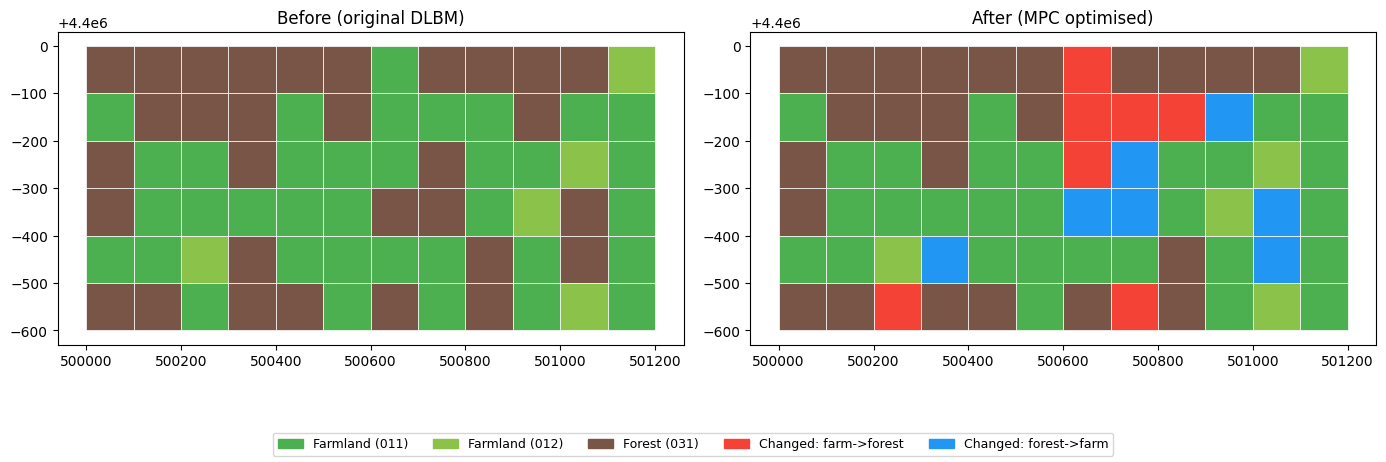


Total parcels changed: 14 / 72


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

original = gpd.read_file(out_shp)
optimized = gpd.read_file(out_shp_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
color_map_before = {'011': '#4CAF50', '012': '#8BC34A', '031': '#795548'}
original['_color'] = original['DLBM'].map(color_map_before).fillna('#BDBDBD')
original.plot(color=original['_color'], edgecolor='white', linewidth=0.5, ax=axes[0])
axes[0].set_title('Before (original DLBM)')
axes[0].set_aspect('equal')

# After (by CHG_FLAG)
def _chg_color(row):
    flag = row.get('CHG_FLAG', 0)
    if flag == 1:
        return '#F44336'  # farm -> forest (red)
    elif flag == 2:
        return '#2196F3'  # forest -> farm (blue)
    else:
        opt = row.get('OPT_DLBM', '')
        return color_map_before.get(opt, '#BDBDBD')

optimized['_color'] = optimized.apply(_chg_color, axis=1)
optimized.plot(color=optimized['_color'], edgecolor='white', linewidth=0.5, ax=axes[1])
axes[1].set_title('After (MPC optimised)')
axes[1].set_aspect('equal')

legend_patches = [
    mpatches.Patch(color='#4CAF50', label='Farmland (011)'),
    mpatches.Patch(color='#8BC34A', label='Farmland (012)'),
    mpatches.Patch(color='#795548', label='Forest (031)'),
    mpatches.Patch(color='#F44336', label='Changed: farm->forest'),
    mpatches.Patch(color='#2196F3', label='Changed: forest->farm'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

n_changed = int((optimized.get('CHG_FLAG', 0) != 0).sum()) if 'CHG_FLAG' in optimized.columns else 0
print(f"\nTotal parcels changed: {n_changed} / {len(optimized)}")

## 8. Summary & next steps

This demo ran the **complete pipeline** on a tiny synthetic fixture. On real county-scale data (2,600 blocks, ~100k parcels), the same pipeline achieves:

| Metric | Paper 9 v6 (Bishan, 5 seeds) |
|--------|------------------------------|
| Slope change | **-1.289% +/- 0.079%** |
| Contiguity | +0.0160 +/- 0.0016 |
| Training cost | 25 min CPU / seed |

To run on your own data:

```bash
conda env create -f environment.yml
conda activate farmland-mpc
farmland-mpc prepare --dltb DLTB.shp --dem DEM.tif --out ./prepared
farmland-mpc sample  --prepared-dir ./prepared
farmland-mpc train   --prepared-dir ./prepared
farmland-mpc plan    --prepared-dir ./prepared --ensemble-dir ./prepared/tool3 --out-dir ./results
```

An ArcGIS Pro toolbox wrapper (`LandUseOptimization_P9.pyt`) is also provided for users who prefer a GUI. See [docs/USER_GUIDE.md](https://github.com/zhouning/arcgis-farmland-mpc/blob/main/docs/USER_GUIDE.md) for full documentation.

**Citation**:

> Zhou, N. *Model-based AI planning enables county-scale farmland consolidation in fragmented mountain landscapes.* In submission, 2026.